In [ ]:
# 1. Klasifikasi Flynn

Klasifikasi Flynn digunakan untuk mengelompokkan arsitektur komputer berdasarkan jumlah aliran instruksi dan aliran data yang dapat diproses.

## a. Operasi `arr + arr` pada NumPy Array

Operasi `arr + arr` pada NumPy dapat dikategorikan sebagai **SIMD (Single Instruction, Multiple Data)**.

Hal ini karena satu operasi yang sama, yaitu operasi penjumlahan, diterapkan pada banyak elemen array secara bersamaan. Dengan menggunakan NumPy, operasi terhadap array dapat dilakukan secara vektor sehingga tidak perlu melakukan perulangan terhadap setiap elemen secara manual.

## b. Program Python Biasa Tanpa Threading/Multiprocessing

Program Python biasa yang membaca file kemudian memprosesnya baris demi baris dapat dikategorikan sebagai **SISD (Single Instruction, Single Data)**.

Program berjalan secara sekuensial, yaitu satu instruksi diproses terhadap satu data pada suatu waktu. Setelah satu baris selesai diproses, program melanjutkan ke baris berikutnya.

Karena program tidak menggunakan threading maupun multiprocessing, tidak terdapat beberapa aliran instruksi yang berjalan secara paralel.

## c. Cluster Komputer dengan Simulasi Cuaca Berbeda

Cluster komputer yang setiap nodenya menjalankan simulasi cuaca untuk wilayah yang berbeda secara independen dapat dikategorikan sebagai **MIMD (Multiple Instruction, Multiple Data)**.

Setiap node dapat menjalankan instruksi dan mengolah data yang berbeda secara bersamaan. Sebagai contoh, satu node menjalankan simulasi cuaca untuk wilayah Sumatra, sedangkan node lain menjalankan simulasi untuk wilayah Jawa atau Kalimantan.

Karena terdapat beberapa aliran instruksi dan beberapa aliran data yang dapat diproses secara independen, skenario ini termasuk **MIMD**.

# 1. Klasifikasi Flynn

Klasifikasi Flynn digunakan untuk mengelompokkan arsitektur komputer berdasarkan jumlah aliran instruksi dan aliran data yang dapat diproses.

## a. Operasi `arr + arr` pada NumPy Array

Operasi `arr + arr` pada NumPy dapat dikategorikan sebagai **SIMD (Single Instruction, Multiple Data)**.

Hal ini karena satu operasi yang sama, yaitu operasi penjumlahan, diterapkan pada banyak elemen array secara bersamaan. Dengan menggunakan NumPy, operasi terhadap array dapat dilakukan secara vektor sehingga tidak perlu melakukan perulangan terhadap setiap elemen secara manual.

## b. Program Python Biasa Tanpa Threading/Multiprocessing

Program Python biasa yang membaca file kemudian memprosesnya baris demi baris dapat dikategorikan sebagai **SISD (Single Instruction, Single Data)**.

Program berjalan secara sekuensial, yaitu satu instruksi diproses terhadap satu data pada suatu waktu. Setelah satu baris selesai diproses, program melanjutkan ke baris berikutnya.

Karena program tidak menggunakan threading maupun multiprocessing, tidak terdapat beberapa aliran instruksi yang berjalan secara paralel.

## c. Cluster Komputer dengan Simulasi Cuaca Berbeda

Cluster komputer yang setiap nodenya menjalankan simulasi cuaca untuk wilayah yang berbeda secara independen dapat dikategorikan sebagai **MIMD (Multiple Instruction, Multiple Data)**.

Setiap node dapat menjalankan instruksi dan mengolah data yang berbeda secara bersamaan. Sebagai contoh, satu node menjalankan simulasi cuaca untuk wilayah Sumatra, sedangkan node lain menjalankan simulasi untuk wilayah Jawa atau Kalimantan.

Karena terdapat beberapa aliran instruksi dan beberapa aliran data yang dapat diproses secara independen, skenario ini termasuk **MIMD**.

In [1]:
pip install matplotlib pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: C:\Users\User\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [3]:
# 2. a. Hitung speedup teoritis untuk N = 2,4,8,16,32,64
import matplotlib.pylot as plt
def amdahl_speedup(P, N):
    return 1 / ((1 - P) + P / N)

P = 0.85
N = [2, 4, 8, 16, 32, 64]
speedup = [amdahl_speedup(P, n) for n in N]

for n, s in zip(N, speedup):
    print(f"N={n:3d} -> Speedup = {s:.4f}")

N=  2 -> Speedup = 1.7391
N=  4 -> Speedup = 2.7586
N=  8 -> Speedup = 3.9024
N= 16 -> Speedup = 4.9231
N= 32 -> Speedup = 5.6637
N= 64 -> Speedup = 6.1244


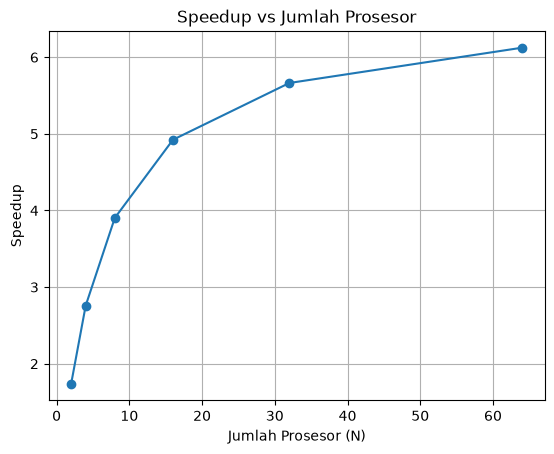

In [6]:
# 2. b. kode untuk speedup
import matplotlib.pyplot as plt
speedup = [amdahl_speedup(P, n) for n in N]

plt.plot(N, speedup, marker='o')
plt.xlabel("Jumlah Prosesor (N)")
plt.ylabel("Speedup")
plt.title("Speedup vs Jumlah Prosesor")
plt.grid(True)
plt.show()

## 2c. Diminishing Returns

Diminishing returns mulai terlihat ketika penambahan jumlah prosesor menghasilkan peningkatan speedup yang semakin kecil. Hal ini disebabkan oleh adanya 15% bagian program yang bersifat serial dan tidak dapat diparalelkan.

Bagian serial tersebut tetap membutuhkan waktu meskipun jumlah prosesor ditambah.

Batas maksimum speedup secara teoritis adalah:

Smax = 1 / (1 - P)
Smax = 1 / 0.15
Smax = 6.67x

Dengan demikian, speedup akan semakin mendekati 6.67x dan tidak dapat meningkat tanpa batas.

In [7]:
## 3a. Membuat Fungsi CPU-Bound
def fibonacci(n):
    if n <= 1:
        return n
    return fibonacci(n - 1) + fibonacci(n - 2)

print("Fibonacci(10) =", fibonacci(10))

Fibonacci(10) = 55


Hasil benchmark:
Input = 2000 | perf_counter = 0.002683 detik | timeit = 0.002253 detik
Input = 4000 | perf_counter = 0.005936 detik | timeit = 0.005329 detik
Input = 6000 | perf_counter = 0.009291 detik | timeit = 0.008737 detik
Input = 8000 | perf_counter = 0.011391 detik | timeit = 0.012420 detik


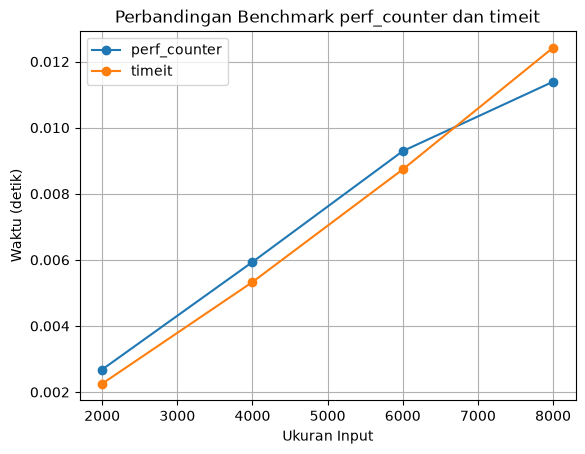

In [4]:
import time, math, timeit
def hitung_prima(n):
    jumlah = 0

    for i in range(2, n):
        prima = True

        for j in range(2, int(math.sqrt(i)) + 1):
            if i % j == 0:
                prima = False
                break

        if prima:
            jumlah += 1

    return jumlah
ukuran_input = [2000, 4000, 6000, 8000]

hasil_perf = []
hasil_timeit = []

for n in ukuran_input:
    # Menggunakan perf_counter()
    start = time.perf_counter()
    hitung_prima(n)
    end = time.perf_counter()

    waktu_perf = end - start
    hasil_perf.append(waktu_perf)

    # Menggunakan timeit
    waktu_timeit = timeit.timeit(
        lambda: hitung_prima(n),
        number=3
    ) / 3

    hasil_timeit.append(waktu_timeit)

print("Hasil benchmark:")
for i in range(len(ukuran_input)):
    print(
        f"Input = {ukuran_input[i]:4d} | "
        f"perf_counter = {hasil_perf[i]:.6f} detik | "
        f"timeit = {hasil_timeit[i]:.6f} detik"
    )
import pandas as pd

tabel_benchmark = pd.DataFrame({
    "Ukuran Input": ukuran_input,
    "perf_counter (detik)": hasil_perf,
    "timeit (detik)": hasil_timeit
})

tabel_benchmark

import matplotlib.pyplot as plt

plt.plot(ukuran_input, hasil_perf, marker='o', label='perf_counter')
plt.plot(ukuran_input, hasil_timeit, marker='o', label='timeit')

plt.xlabel("Ukuran Input")
plt.ylabel("Waktu (detik)")
plt.title("Perbandingan Benchmark perf_counter dan timeit")
plt.legend()
plt.grid(True)
plt.show()

### Analisis Hasil Benchmark

Berdasarkan hasil benchmark, waktu eksekusi fungsi Fibonacci meningkat ketika ukuran input semakin besar. Hal ini disebabkan oleh banyaknya pemanggilan fungsi secara rekursif.

Pada input yang lebih kecil, waktu eksekusi relatif singkat. Ketika nilai n diperbesar, jumlah operasi meningkat dengan cepat sehingga waktu eksekusi juga semakin lama.

Hasil pengukuran menggunakan `time.perf_counter()` dan `timeit` dapat memiliki perbedaan nilai karena metode pengukuran dan kondisi sistem yang digunakan berbeda. Namun, keduanya menunjukkan pola yang sama, yaitu waktu eksekusi meningkat seiring bertambahnya ukuran input.

## 4. Refleksi Singkat

Hukum Amdahl lebih relevan digunakan ketika ukuran masalah relatif tetap dan ingin mengetahui seberapa besar peningkatan performa dengan menambah jumlah prosesor. Hukum ini memperhitungkan bagian program yang tidak dapat diparalelkan sehingga menunjukkan adanya batas speedup. Contohnya adalah pengolahan gambar dengan ukuran tetap menggunakan beberapa prosesor.

Sementara itu, Hukum Gustafson lebih relevan ketika jumlah prosesor bertambah dan ukuran masalah juga dapat diperbesar. Dengan sumber daya yang lebih banyak, sistem dapat menyelesaikan masalah yang lebih besar dalam waktu yang relatif sama. Contohnya adalah simulasi cuaca yang menggunakan lebih banyak komputer untuk memproses wilayah atau resolusi simulasi yang lebih besar.

Dengan demikian, Amdahl berfokus pada masalah dengan ukuran tetap, sedangkan Gustafson menekankan peningkatan ukuran masalah seiring bertambahnya sumber daya.